In [ ]:
# install image with file id
!gdown '1_N8qe3XWwKbCeXKAkvH8gnR-Uvcvd5i2'

Downloading...
From: https://drive.google.com/uc?id=1_N8qe3XWwKbCeXKAkvH8gnR-Uvcvd5i2
To: /content/LAB03 PIC1.png
100% 729k/729k [00:00<00:00, 89.7MB/s]


# Section 1
Read and show the image

In [2]:
# install image with file id
!gdown '1_N8qe3XWwKbCeXKAkvH8gnR-Uvcvd5i2'

Downloading...
From: https://drive.google.com/uc?id=1_N8qe3XWwKbCeXKAkvH8gnR-Uvcvd5i2
To: /content/LAB03 PIC1.png
100% 729k/729k [00:00<00:00, 10.8MB/s]


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow

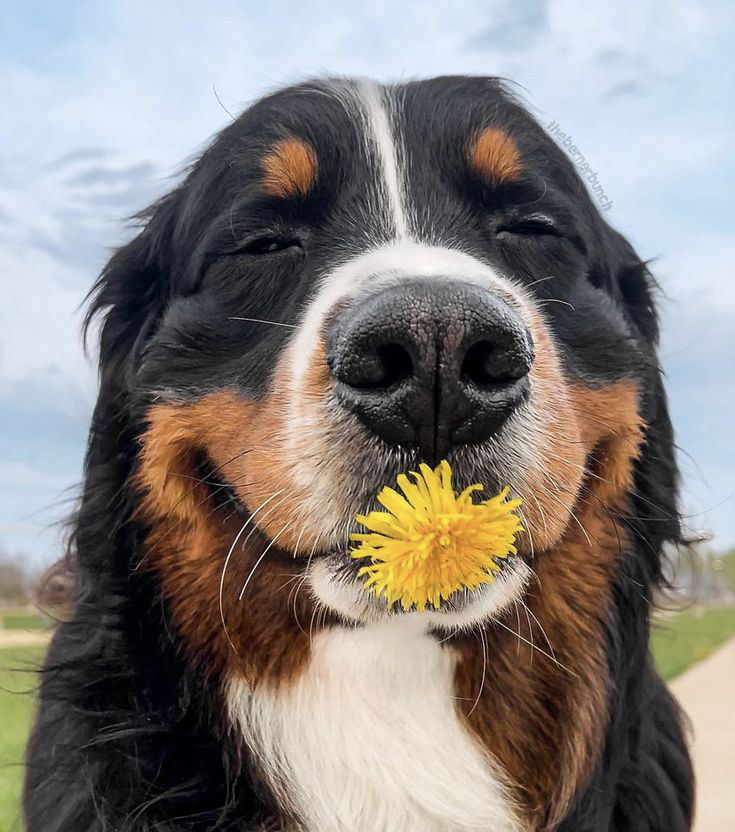

In [4]:
# Answer your code here
img = cv.imread('/content/LAB03 PIC1.png')
img
cv2_imshow(img)

# Section 2
Use cv.resize() for scaling the image to 50% of the original size and show the results.

In [5]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
img.shape

(832, 735, 3)

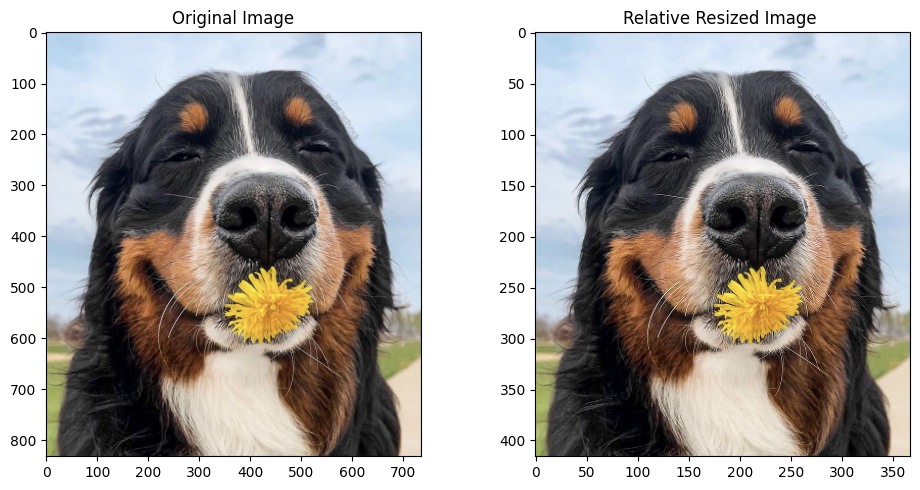

In [7]:
# Answer your code here
# height,width=img.shape[:2]

rel_res = cv.resize(img,None,fx=.5, fy=.5, interpolation = cv.INTER_CUBIC)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title("Relative Resized Image ")
plt.imshow(cv.cvtColor(rel_res, cv.COLOR_BGR2RGB))

plt.tight_layout()
plt.show()

# Section 3
Apply theory of *object tracking* to extract blue colored of dog image and

write the code to:

  1. Convert from BGR to HSV color-space.  (Use image from section 1)
  2. Threshold the HSV image for a range of blue color.
  3. Extract only the blue position of image.

  



In [8]:
blue = np.uint8([[[0,255,0 ]]])
hsv_blue = cv.cvtColor(blue,cv.COLOR_BGR2HSV) # I changed the YCrCr to HSV to make it easier for me
print(hsv_blue)

[[[ 60 255 255]]]


Masking


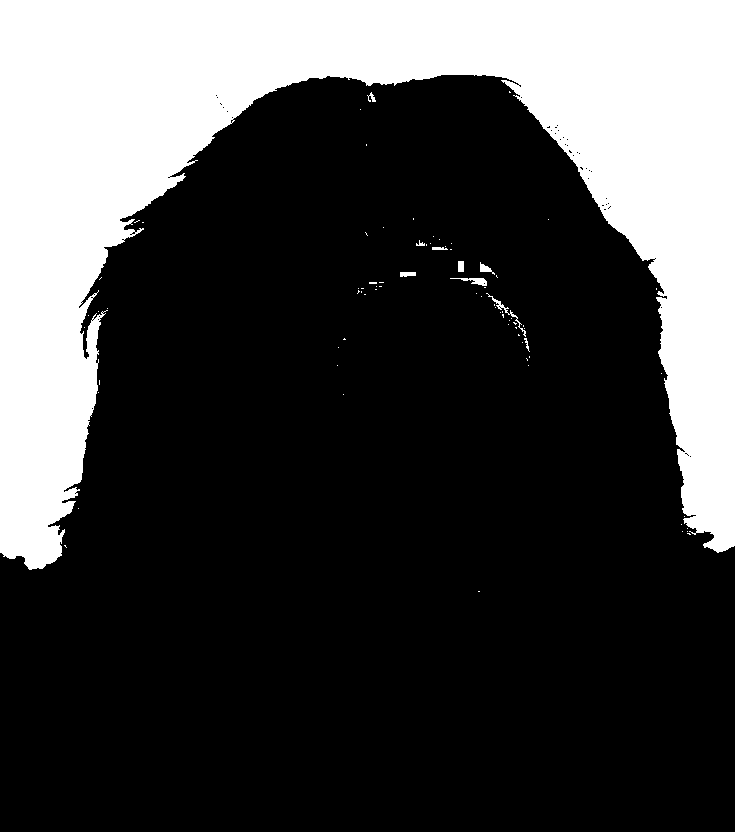

----------------------------------------------------------------------------------------------------
HSV


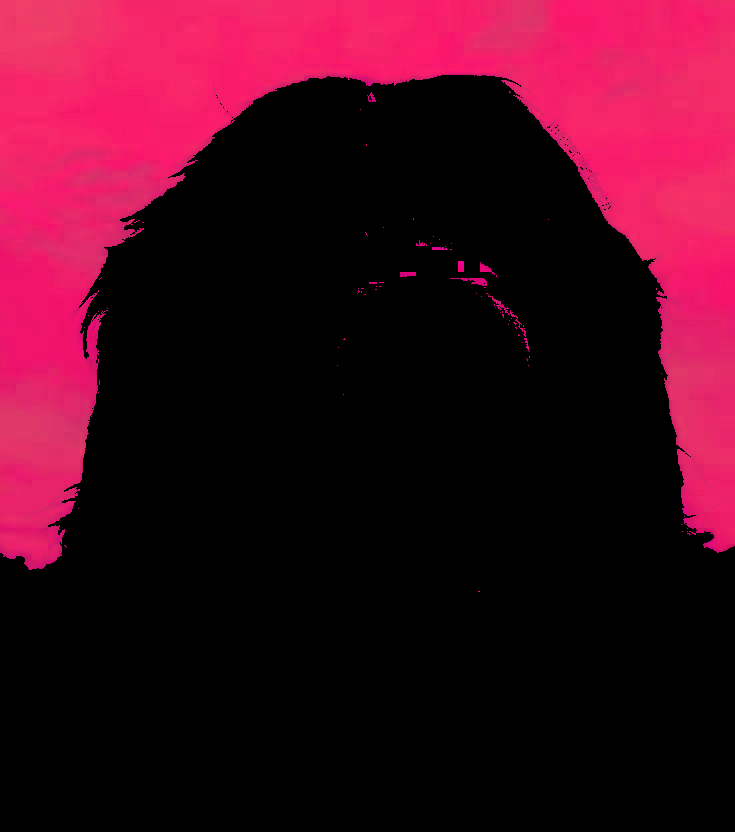

----------------------------------------------------------------------------------------------------
Original


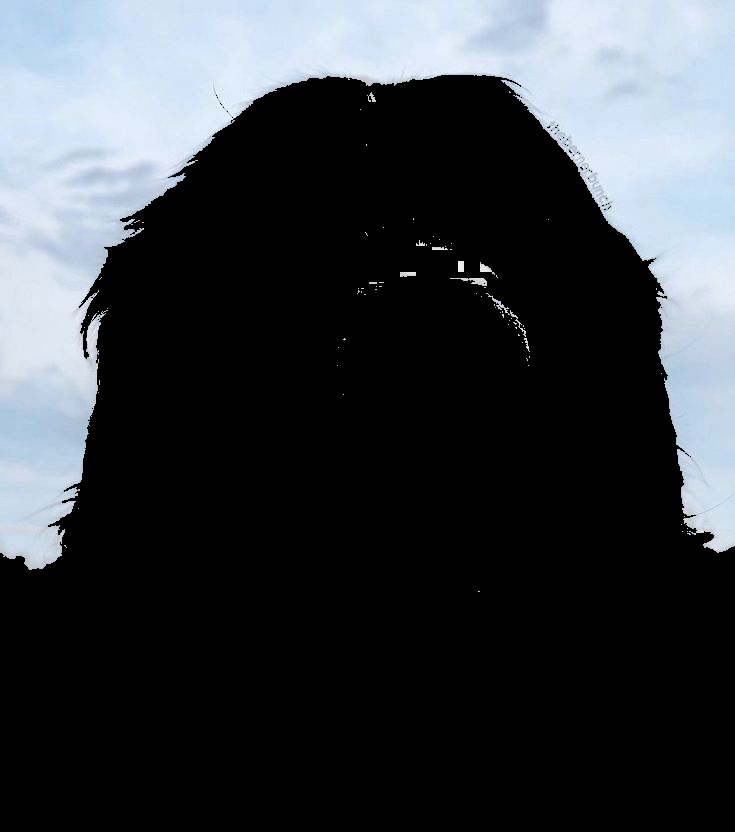

In [9]:
# Answer your code here
img_hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
img_hsv

lower_blue=np.array([80,0,200])
upper_blue=np.array([140,255,255])

mask = cv.inRange(img_hsv, lower_blue, upper_blue)
res = cv.bitwise_and(img_hsv, img_hsv, mask=mask)
og = cv.bitwise_and(img, img, mask=mask)

print("Masking")
cv2_imshow(mask)
print("-"*100)
print("HSV")
cv2_imshow(res)
print("-"*100)
print("Original")
cv2_imshow(og)

Another object tracking in dog image try to extract only yellow colored of flower.

write the code to:

1. Convert from BGR to HSV color-space. (Use image from section 1)
2. Threshold the HSV image for a range of yellow color.
3. Extract only the yellow position of image.

In [10]:
yellow = np.uint8([[[0,10,0 ],[0,50,0 ],[0,100,0 ],[0,200,0 ],[0,255,0 ]]])
hsv_yellow = cv.cvtColor(yellow,cv.COLOR_BGR2HSV)
print(hsv_yellow)

[[[ 60 255  10]
  [ 60 255  50]
  [ 60 255 100]
  [ 60 255 200]
  [ 60 255 255]]]


Masking


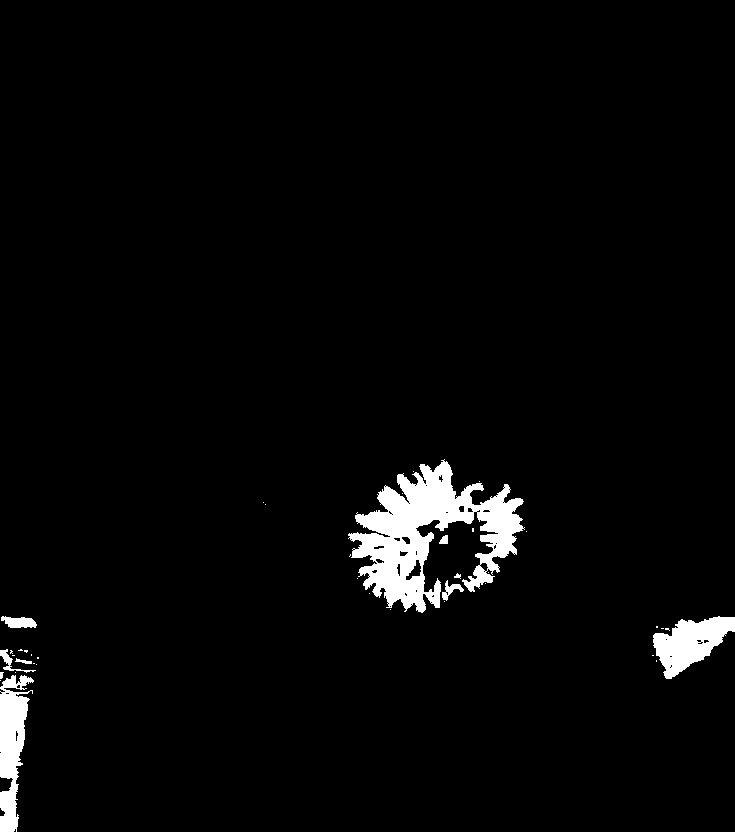

----------------------------------------------------------------------------------------------------
HSV


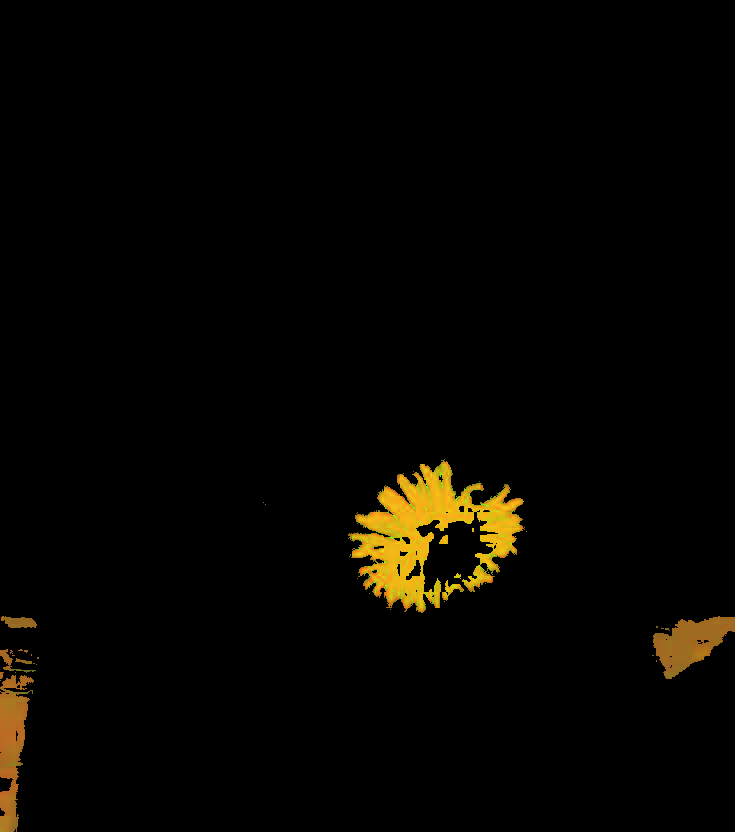

----------------------------------------------------------------------------------------------------
Original


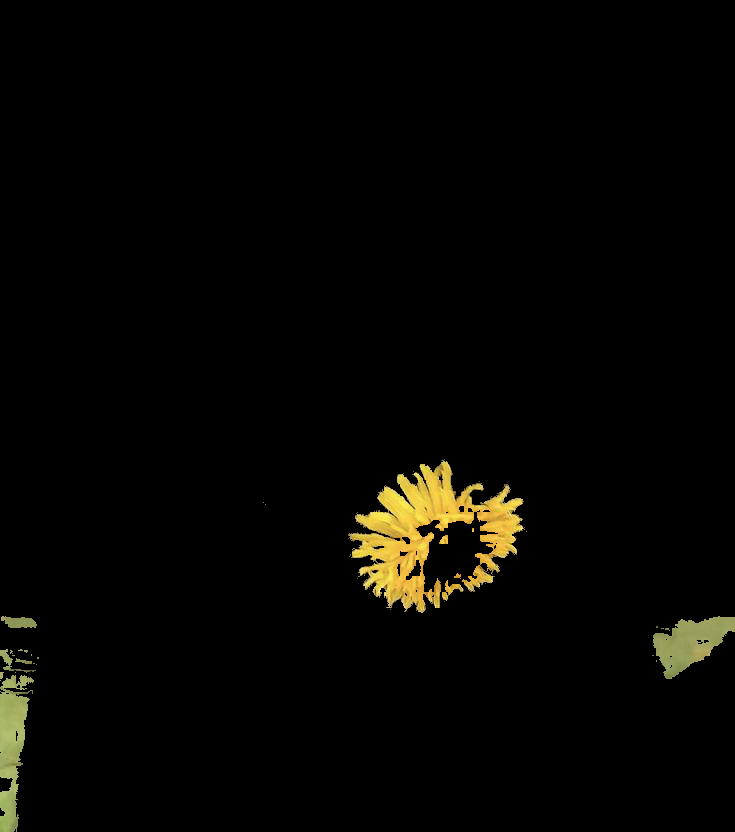

In [11]:
# Answer your code here
img_hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
img_hsv

lower_yellow = np.array([20, 100, 100])
upper_yellow = np.array([100, 255, 255])

mask = cv.inRange(img_hsv, lower_yellow, upper_yellow)
res = cv.bitwise_and(img_hsv, img_hsv, mask=mask)
og = cv.bitwise_and(img, img, mask=mask)

print("Masking")
cv2_imshow(mask)
print("-"*100)
print("HSV")
cv2_imshow(res)
print("-"*100)
print("Original")
cv2_imshow(og)

# Section 4
Use the cv.getRotationMatrix2D() and cv.warpAffine() functions and write the code to:

  1. Rotate an image around its center at 45 degrees without scaling.
  2. Rotate the same image around its center at 45 degrees with two different scaling factors like: 0.75, 1.5, etc.
  3. Display the results and explain the impact of the scaling factor on the output.

  



In [12]:
rows,cols,channels  = img.shape

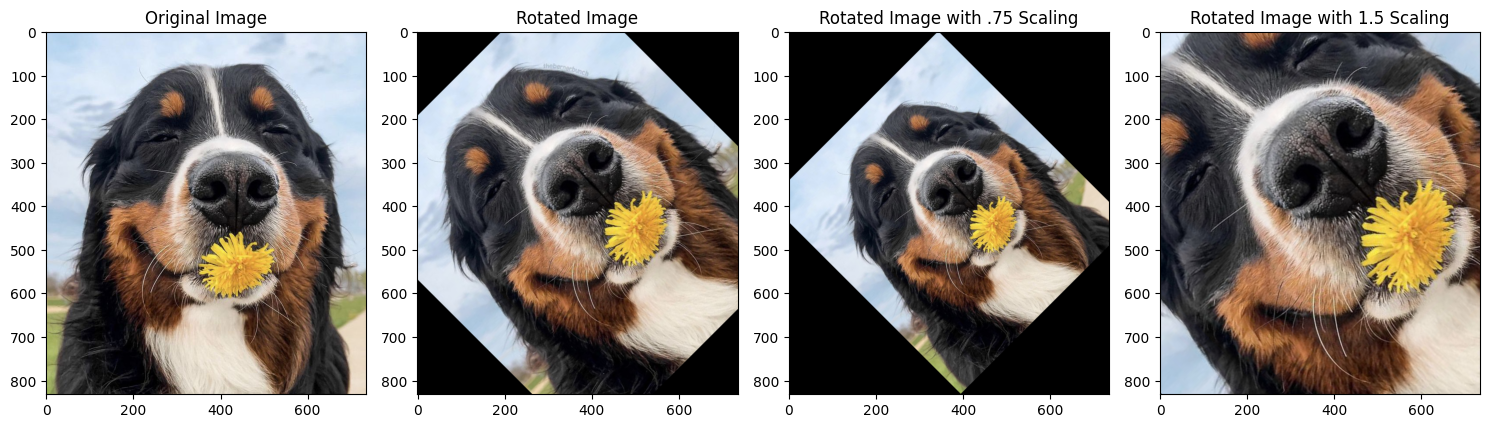

In [16]:
# Use same image "LAB03 PIC1.png"
# Answer your code here
RGB_img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
# 1. Generate the Rotation Matrix
M = cv.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),45,1)
M2 = cv.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),45,.75) # scaled down by 25%
M3 = cv.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),45,1.5) # scaled up by 50%

# 2. Rotate
rotated_img = cv.warpAffine(RGB_img,M,(cols,rows))
rotated_img2 = cv.warpAffine(RGB_img,M2,(cols,rows))
rotated_img3 = cv.warpAffine(RGB_img,M3,(cols,rows))

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title("Original Image")
plt.imshow(RGB_img, cmap='gray')

plt.subplot(1, 4, 2)
plt.title("Rotated Image")
plt.imshow(rotated_img, cmap='gray')

plt.subplot(1, 4, 3)
plt.title("Rotated Image with .75 Scaling")
plt.imshow(rotated_img2, cmap='gray')

plt.subplot(1, 4, 4)
plt.title("Rotated Image with 1.5 Scaling")
plt.imshow(rotated_img3, cmap='gray')

plt.tight_layout()
plt.show()

In [17]:
# Explanation
# if smaller factor or scaling factor (<1) it will shrink the image, making it easier to retain the rotated content within the frame
# if larger factor or scaling factor (>1) it will enlarge the image, losing more content outside the frame after rotation or even not rotating.

# Section 5
 Use cv.getAffineTransform() and cv.warpAffine() functions to apply an affine transformation to an image， use the following points and the input image as the code '1U_l68HuSK9B8DvpOqEf6R2Gs-Ok0rsS6' and then display the results.
- Input points: [[50, 50], [200, 50], [50, 200]]
- Output points:
  1. Output points:[[10, 100], [200, 50], [100, 250]]
  2. Output points:[[50, 200], [200, 50], [100, 250]]

In [18]:
!gdown '1U_l68HuSK9B8DvpOqEf6R2Gs-Ok0rsS6'

Downloading...
From: https://drive.google.com/uc?id=1U_l68HuSK9B8DvpOqEf6R2Gs-Ok0rsS6
To: /content/checkerboard.png
100% 67.7k/67.7k [00:00<00:00, 4.43MB/s]


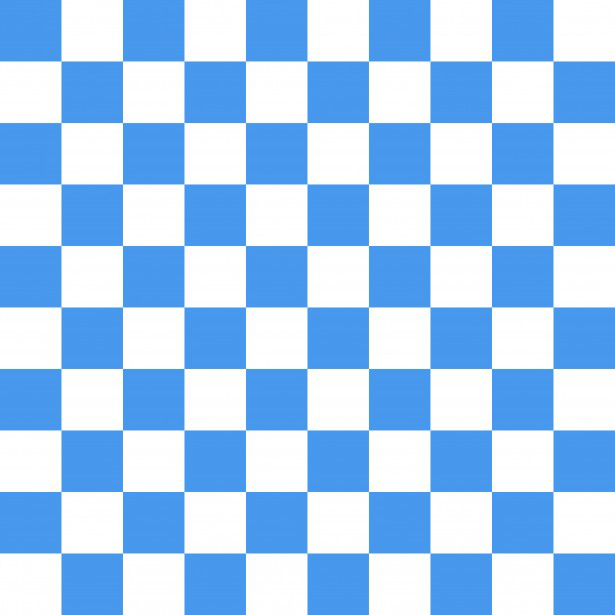

In [19]:
# Answer your code here
checkboard = cv.imread('/content/checkerboard.png')
cv2_imshow(checkboard)

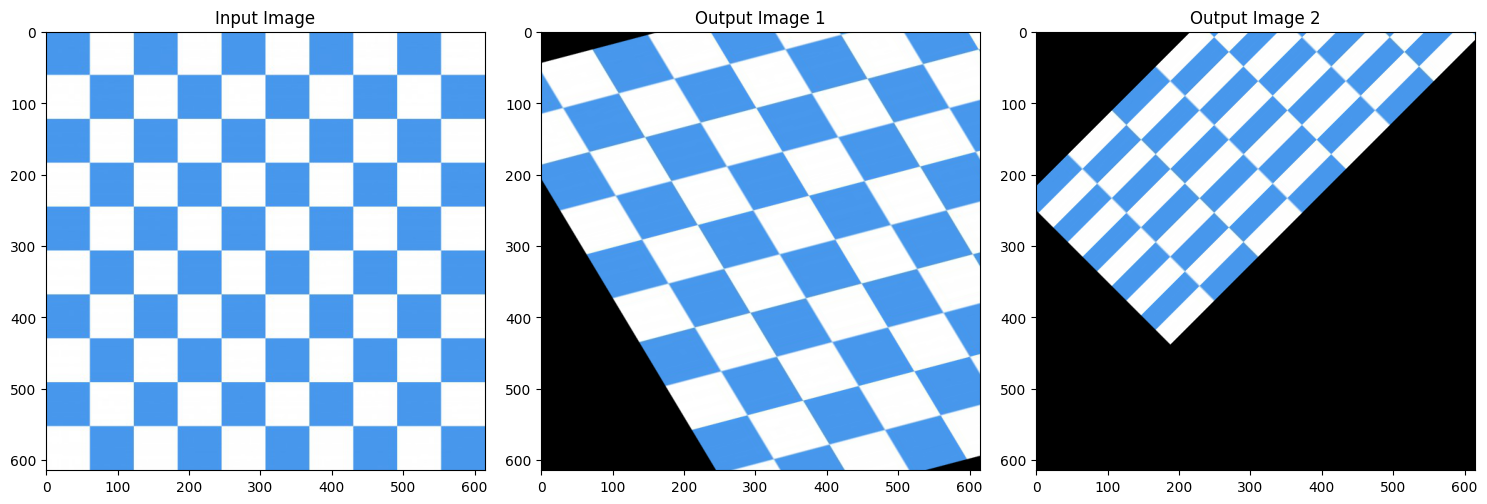

In [22]:
# Answer your code here
rows, cols = checkboard.shape[:2]

# Define input and output points
# pts1 = np.float32([[x1, y1], [x2, y2], [x3, y3]])
pts1 = np.float32([[50, 50], [200, 50], [50, 200]]) # points in the input image

pts2 = np.float32([[10, 100], [200, 50], [100, 250]])# points in the output image.
pts3 = np.float32([[50, 200], [200, 50], [100, 250]])# points in the output image.

# 1. Calculate Affine Transformation Matrix
M1 = cv.getAffineTransform(pts1, pts2)
M2 = cv.getAffineTransform(pts1, pts3)

# 2. Affine Transform
Affine_transformed1 = cv.warpAffine(checkboard, M1, (cols, rows)) # output size col and row
Affine_transformed2 = cv.warpAffine(checkboard, M2, (cols, rows)) # output size col and row

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(checkboard, cv.COLOR_BGR2RGB))
plt.title('Input Image')

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(Affine_transformed1, cv.COLOR_BGR2RGB))
plt.title('Output Image 1')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(Affine_transformed2, cv.COLOR_BGR2RGB))
plt.title('Output Image 2')

plt.tight_layout()
plt.show()


# Section 6
Given the coordinates of a quadrilateral region in an image (pts1) and the corresponding points for a rectangular output (pts2) as follow：

- pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])

- pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])
- output size as (300,300)

To do:
  1. Compute the transformation matrix using cv.getPerspectiveTransform().
  2. Apply the perspective transformation to the input image using cv.warpPerspective() with the specified output size (300, 300).

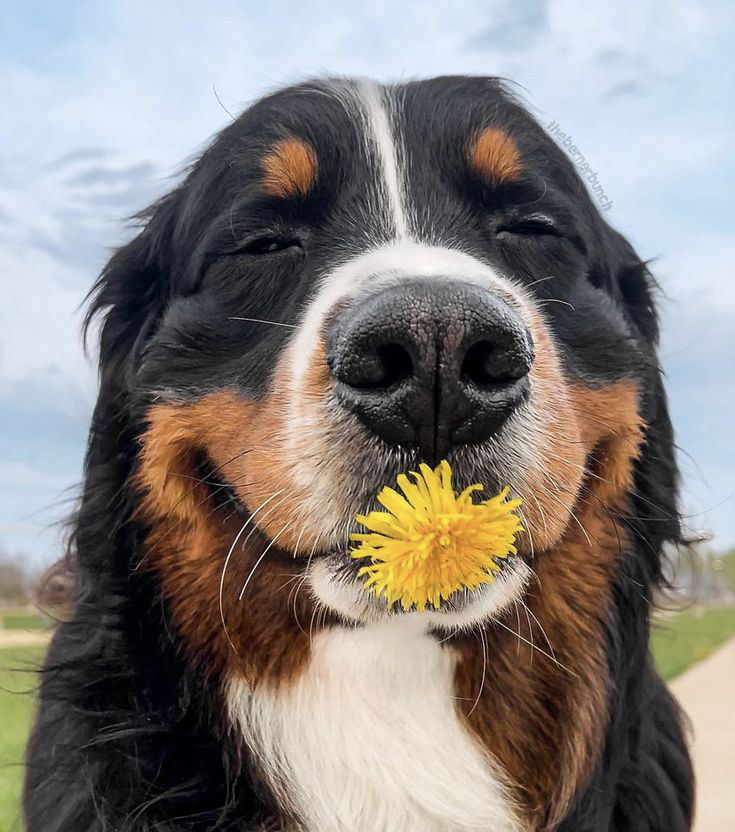

In [24]:
# Use same image "LAB03 PIC1.png"
# Answer your code here
img = cv.imread('/content/LAB03 PIC1.png')
cv2_imshow(img)
rows, cols = img.shape[:2]

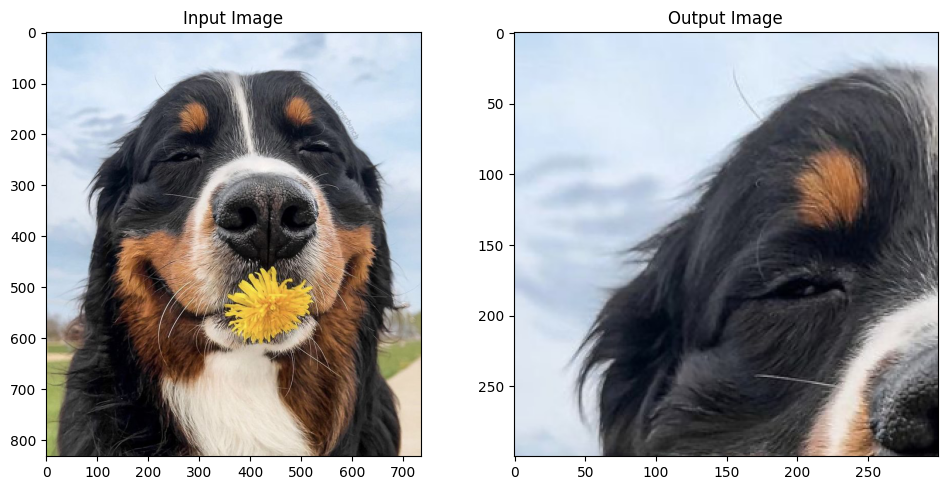

In [26]:
# Define the input and outpoints
pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])

# 1. Generate perspective transform matrix
M = cv.getPerspectiveTransform(pts1,pts2)

# 2. Perspective transform
Perspective_transformed = cv.warpPerspective(img,M,(300,300))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(Perspective_transformed, cv.COLOR_BGR2RGB))
plt.title('Output Image')

plt.tight_layout()
plt.show()

In [58]:
M

array([[ 1.05587376e+00,  9.18151097e-02, -6.50969128e+01],
       [ 4.69010049e-02,  1.12562412e+00, -7.57920240e+01],
       [ 1.83251448e-04,  5.13337001e-04,  1.00000000e+00]])

#Section 7
You need to download new image from the link below (pancake.png). If I want you to create image that has only outline image (follow image below) for giving kids paint the part inside outline of pancake image. Which image thresholding solution will you use to get this type of pancake image ?

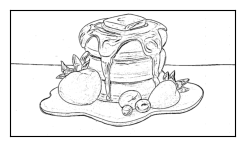

In [27]:
!gdown '1F377cD-enYDoLSOibSKEZ1oqyqkJ61a8'

Downloading...
From: https://drive.google.com/uc?id=1F377cD-enYDoLSOibSKEZ1oqyqkJ61a8
To: /content/pancake.png
100% 311k/311k [00:00<00:00, 6.17MB/s]


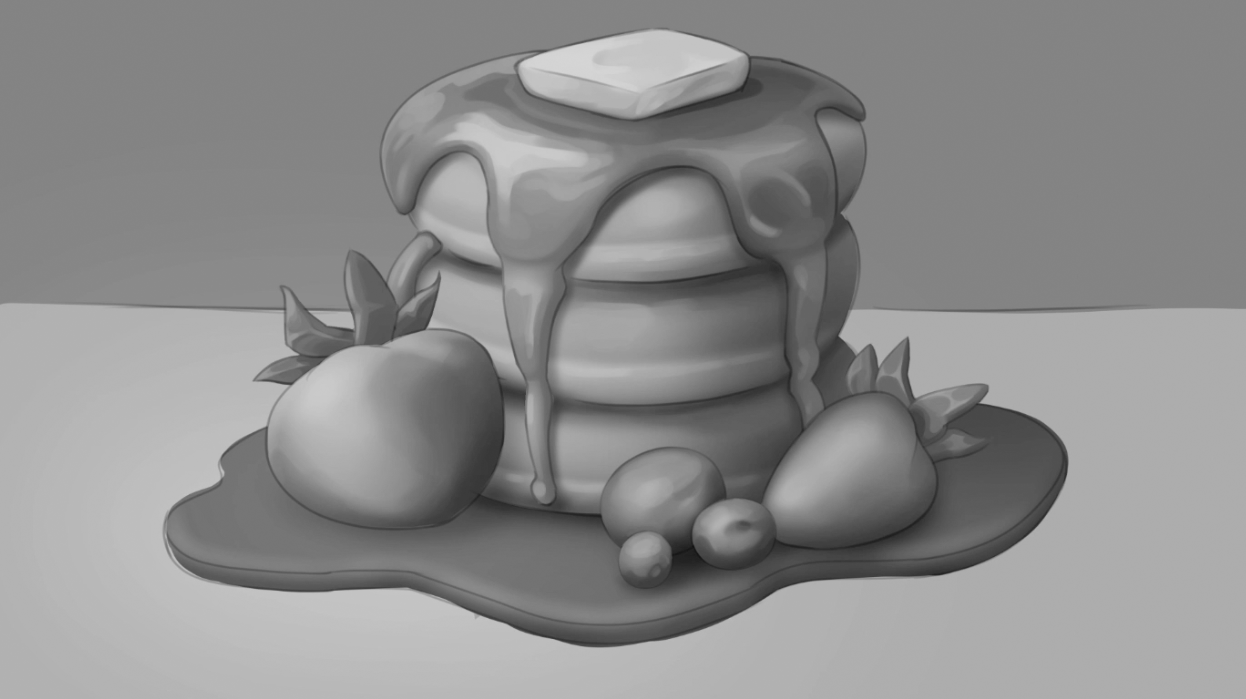

In [29]:
# Answer your code here
pancake = cv.imread('/content/pancake.png', cv.IMREAD_GRAYSCALE)
cv2_imshow(pancake)

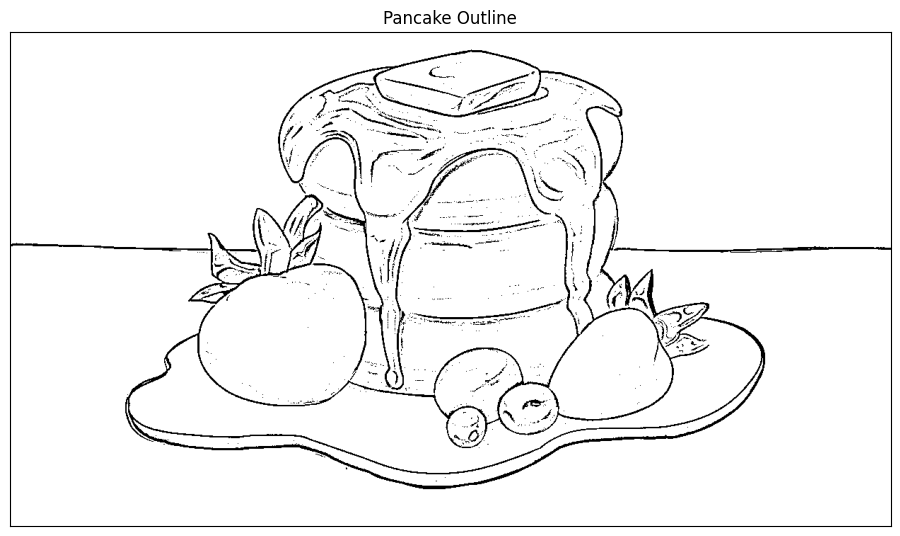

In [57]:
th = cv.adaptiveThreshold(pancake, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 3)

plt.figure(figsize=(25, 10))
plt.subplot(1,2,1),plt.imshow(th,'gray')
plt.title('Pancake Outline')
plt.xticks([]),plt.yticks([])
plt.show()